In [70]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns

In [5]:
dataset = pd.read_csv('student_scores.csv')
dataset.head()

,Hours,Scores
0,2.5,21
1,5.1,47
2,3.2,27
3,8.5,75
4,3.5,30


In [8]:
dataset.shape

(25, 2)

In [11]:
dataset.ndim

2

In [12]:
dataset.describe()

,Hours,Scores
count,25.000000,25.000000
mean,5.012000,51.480000
std,2.525094,25.286887
min,1.100000,17.000000
25%,2.700000,30.000000
50%,4.800000,47.000000
75%,7.400000,75.000000
max,9.200000,95.000000


In [18]:
print(len(dataset['Hours'].value_counts()))
print(type(dataset['Hours'].value_counts()))
# dataset['Hours'].value_counts()

23
<class 'pandas.core.series.Series'>


In [19]:
print(len(dataset['Hours'].unique()))
print(type(dataset['Hours'].unique()))
dataset['Hours'].unique()

23
<class 'numpy.ndarray'>


array([2.5, 5.1, 3.2, 8.5, 3.5, 1.5, 9.2, 5.5, 8.3, 2.7, 7.7, 5.9, 4.5,
       3.3, 1.1, 8.9, 1.9, 6.1, 7.4, 4.8, 3.8, 6.9, 7.8])

In [22]:
print(len(dataset['Scores'].value_counts()))
print(type(dataset['Scores'].value_counts()))
# dataset['Hours'].value_counts()

23
<class 'pandas.core.series.Series'>


In [24]:
print(len(dataset['Scores'].unique()))
print(type(dataset['Scores'].unique()))
dataset['Scores'].unique()

23
<class 'numpy.ndarray'>


array([21, 47, 27, 75, 30, 20, 88, 60, 81, 25, 85, 62, 41, 42, 17, 95, 24,
       67, 69, 54, 35, 76, 86], dtype=int64)

In [29]:
print(len(dataset['Hours'].values))
print(type(dataset['Hours'].values))
dataset['Hours'].values

25
<class 'numpy.ndarray'>


array([2.5, 5.1, 3.2, 8.5, 3.5, 1.5, 9.2, 5.5, 8.3, 2.7, 7.7, 5.9, 4.5,
       3.3, 1.1, 8.9, 2.5, 1.9, 6.1, 7.4, 2.7, 4.8, 3.8, 6.9, 7.8])

<Axes: ylabel='Density'>

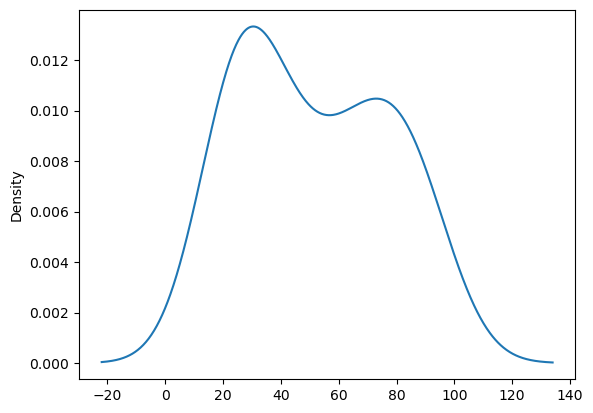

In [43]:
dataset['Scores'].plot(kind='density')
# dataset['Hours'].plot(kind = 'kde')

<Axes: ylabel='Density'>

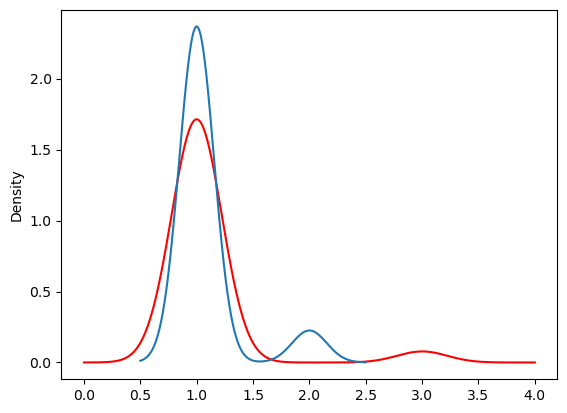

In [63]:
dataset['Scores'].value_counts().plot(kind='density', color = 'red')
dataset['Hours'].value_counts().plot(kind='density')

<Axes: xlabel='Hours', ylabel='Scores'>

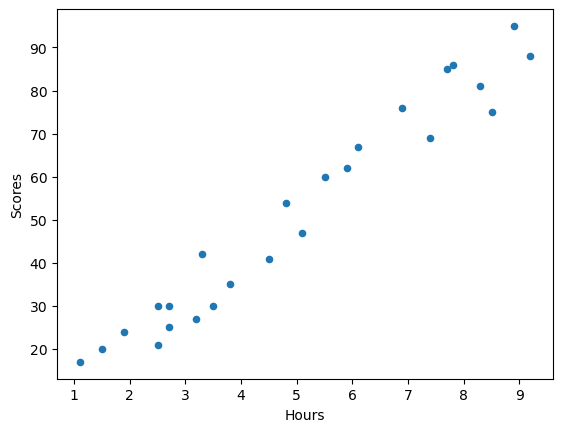

In [56]:
dataset.plot(kind='scatter', x = 'Hours', y = 'Scores')

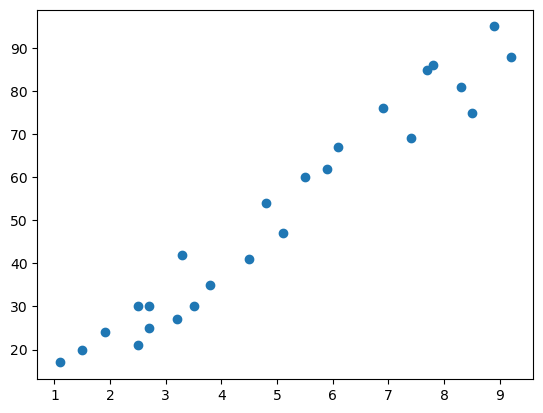

In [64]:
plt.scatter(x = dataset['Hours'], y = dataset['Scores'])

<Axes: xlabel='Hours', ylabel='Scores'>

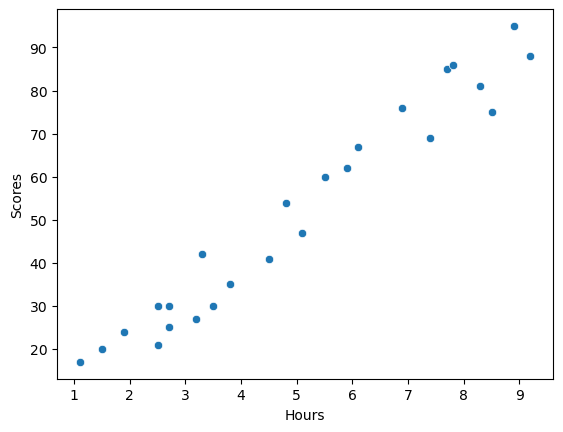

In [65]:
sns.scatterplot(x = dataset['Hours'], y = dataset['Scores'])

<Axes: xlabel='Hours', ylabel='Scores'>

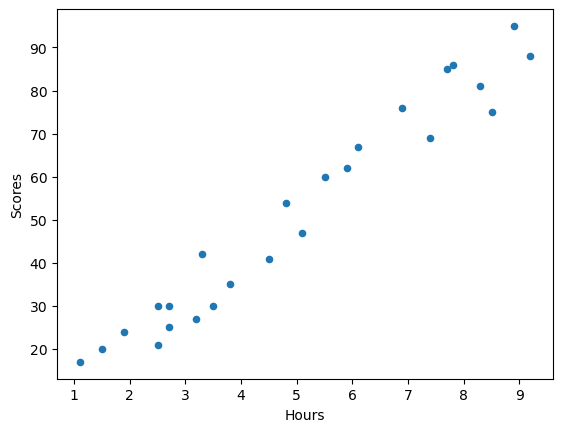

In [69]:
dataset.plot.scatter(x = 'Hours', y = 'Scores')

In [187]:
X = dataset.iloc[:,:-1]
y = dataset.iloc[:,-1]

In [108]:
from sklearn.model_selection import train_test_split

In [188]:
X_train, X_test, y_train, y_test = train_test_split(X,y, train_size = 0.7, random_state=42)

In [191]:
y_train

22    35
5     20
2     27
12    41
15    95
3     75
4     30
20    30
17    24
21    54
18    67
24    86
7     60
10    85
14    17
19    69
6     88
Name: Scores, dtype: int64

<Axes: xlabel='Hours', ylabel='Scores'>

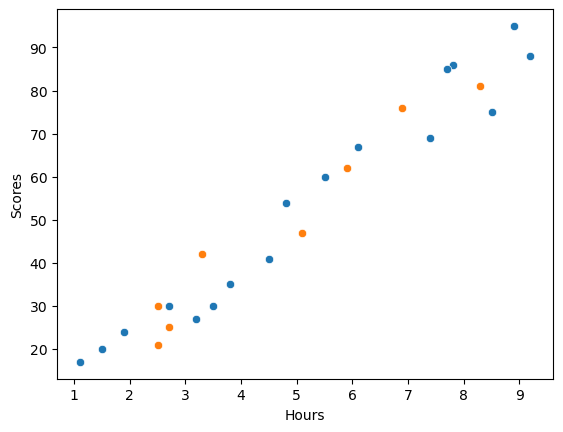

In [194]:
X_train, X_test, y_train, y_test = train_test_split(X,y, train_size = 0.7, random_state=42)
# it treats X_train as a whole dataframe (indeces and real columns) so at least it has two columns,
# so I must specify which columns I want to display
sns.scatterplot(x = X_train['Hours'], y = y_train)
sns.scatterplot(x = X_test['Hours'], y = y_test)

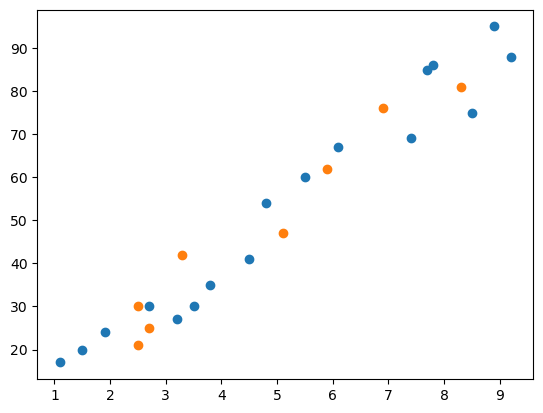

In [196]:
plt.scatter(X_train,y_train)
plt.scatter(X_test,y_test)

In [197]:
from sklearn.linear_model import LinearRegression

In [198]:
model = LinearRegression()
model.fit(X_train,y_train)
model

LinearRegression()

In [199]:
y = model.predict(X_train)
type(y)

numpy.ndarray

In [202]:
y_train

22    35
5     20
2     27
12    41
15    95
3     75
4     30
20    30
17    24
21    54
18    67
24    86
7     60
10    85
14    17
19    69
6     88
Name: Scores, dtype: int64

In [201]:
y

array([39.69425223, 17.36000808, 33.86792767, 46.49163089, 89.21801101,
       85.33379464, 36.78108995, 29.0126572 , 21.24422446, 49.40479317,
       62.02849639, 78.53641598, 56.20217183, 77.56536189, 13.47579171,
       74.65219961, 92.13117329])

<Axes: xlabel='Hours', ylabel='Scores'>

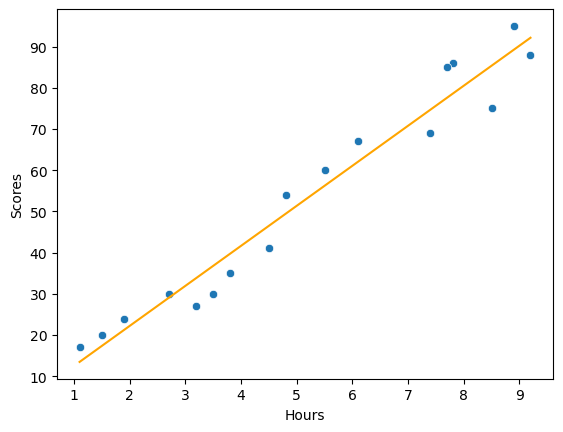

In [208]:
sns.scatterplot(x = X_train['Hours'], y = y_train)
sns.lineplot(x = X_train['Hours'], y = y,color='orange')

In [209]:
y_predict = model.predict(X_test)
type(y_predict)

numpy.ndarray

In [210]:
y_predict

array([83.39168645, 27.07054902, 27.07054902, 69.79692914, 60.0863882 ,
       29.0126572 , 34.83898177, 52.31795545])

In [211]:
y_test

8     81
16    30
0     21
23    76
11    62
9     25
13    42
1     47
Name: Scores, dtype: int64

<Axes: xlabel='Hours', ylabel='Scores'>

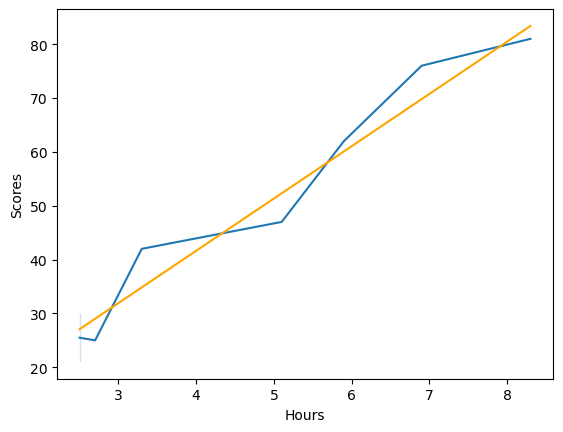

In [214]:
sns.lineplot(x = X_test['Hours'], y = y_test)
sns.lineplot(x = X_test['Hours'], y = y_predict, color='orange')

In [215]:
model.score(X_test, y_test)

0.9487647340257012